## Extraer características

El objetivo de este notebook es extraer las características necesarias entre el cuerpo de la noticia que puedan dar indicios de clickbait y ver si se diferencia en el espacio reducido con el UMAP

### Librerías

In [1]:
import spacy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import json
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity


import nltk
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize
from sentence_transformers import SentenceTransformer
from umap import UMAP


from sentence_transformers import CrossEncoder
from scipy.special import expit


import re
from nltk.tokenize import word_tokenize
from sklearn.preprocessing import StandardScaler

nltk.download("punkt")
nltk.download('stopwords')
nlp = spacy.load("es_core_news_sm")
stop = stopwords.words('spanish')


embedding_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-mpnet-base-v2") # paraphrase-multilingual-mpnet-base-v2 paraphrase-multilingual-MiniLM-L12-v2


/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
I0000 00:00:1778753387.263961   46044 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778753389.201438   46044 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
[nltk_data] Downloading package punkt to /home/javier/nltk_data...
[nltk_data]   Package punk

### Funciones principales

In [2]:
def dividir_contenido(texto, palabras_por_fragmento=15):
    palabras = texto.split()
    fragmentos = []
    for i in range(0, len(palabras), palabras_por_fragmento):
        fragmento = " ".join(palabras[i:i + palabras_por_fragmento])
        fragmentos.append(fragmento)
    return fragmentos

def cargar_datos(noticias, n_noticia=0, print_info=False):
    """
    Carga título y contenido de una noticia
    input: n_noticia (int): índice de noticia
    output: titulo, fragmentos_contenido (list)
    """
    noticia = noticias[n_noticia]
    titulo = noticia["Título"]
    contenido = noticia["Contenido"]
    # fragmentos_contenido = sent_tokenize(contenido, language='spanish')
    fragmentos_contenido = dividir_contenido(contenido, palabras_por_fragmento=15)
    if print_info:
        print(f"Título: {titulo}\n")
        print(f"\nFragmentos:")
        for i, frag in enumerate(fragmentos_contenido, 1):
            print(f"  Fragmento {i}: {frag}")
    
    return titulo, fragmentos_contenido,noticia


def extraer_features_linguisticos(corpus):
    """
    Extrae features lingüísticas relacionadas con clickbait.

    Parameters
    ----------
    corpus : list[str]
        Lista de textos.

    Returns
    -------
    np.ndarray
        Array shape (n_textos, n_features)
    """

    # =====================================================
    # Diccionarios léxicos
    # =====================================================

    deicticos = {
        'yo', 'tú', 'tu', 'usted', 'ustedes',
        'él', 'ella', 'ellos', 'ellas',
        'nosotros', 'nosotras',
        'vosotros', 'vosotras',
        'me', 'te', 'se', 'nos', 'os',
        'le', 'les',
        'mi', 'mis',
        'tus', 'su', 'sus',
        'nuestro', 'nuestra',
        'vuestro', 'vuestra',
        'este', 'esta', 'estos', 'estas',
        'ese', 'esa', 'esos', 'esas',
        'aquel', 'aquella',
        'aquí', 'ahí', 'allí',
        'ahora', 'hoy', 'mañana',
        'esto', 'eso', 'aquello'
    }

    intensificadores = {
        'muy', 'sumamente', 'extremadamente',
        'increíblemente', 'absolutamente',
        'totalmente', 'completamente',
        'realmente', 'verdaderamente',
        'demasiado', 'especialmente',
        'particularmente', 'sorprendentemente',
        'brutalmente', 'impresionantemente',
        'enormemente', 'terriblemente'
    }

    superlativos = {
        'mejor', 'peor', 'máximo', 'mínimo',
        'mayor', 'menor', 'último', 'primero',
        'buenísimo', 'malísimo',
        'importantísimo', 'gravísimo',
        'rarísimo', 'famosísimo',
        'enormísimo'
    }

    emocionales = {
        'increíble', 'impactante',
        'sorprendente', 'brutal',
        'impresionante', 'escandaloso',
        'alarmante', 'insólito',
        'inesperado', 'viral',
        'polémico', 'emocionante',
        'dramático', 'sorprendido',
        'devastador', 'terrible',
        'histórico', 'explosivo'
    }

    curiosity_gap = {
        'no creerás',
        'nadie esperaba',
        'lo que pasó',
        'te sorprenderá',
        'se vuelve viral',
        'está arrasando',
        'deja sin palabras',
        'causa furor',
        'no podrás creer',
        'todo el mundo habla',
        'revoluciona las redes',
        'se hace viral'
    }

    # =====================================================
    # Extracción de features
    # =====================================================

    features = []

    for texto in corpus:

        texto_lower = texto.lower()

        palabras = word_tokenize(
            texto_lower,
            language="spanish"
        )

        n_palabras = max(len(palabras), 1)

        # -----------------------------
        # Conteos léxicos
        # -----------------------------

        deicticos_count = sum(
            1 for p in palabras
            if p in deicticos
        )

        intensificadores_count = sum(
            1 for p in palabras
            if p in intensificadores
        )

        emocionales_count = sum(
            1 for p in palabras
            if p in emocionales
        )

        superlativos_count = sum(
            1 for p in palabras
            if (
                p in superlativos
                or any(
                    suf in p
                    for suf in [
                        'ísimo',
                        'ísima',
                        'ísimos',
                        'ísimas'
                    ]
                )
            )
        )

        # -----------------------------
        # Curiosity gap
        # -----------------------------

        curiosity_count = sum(
            1 for expr in curiosity_gap
            if expr in texto_lower
        )

        # -----------------------------
        # Puntuación
        # -----------------------------

        exclamaciones = len(
            re.findall(r'[!¡]', texto)
        )

        interrogaciones = len(
            re.findall(r'[?¿]', texto)
        )

        puntos_suspensivos = texto.count("...")

        mayusculas = len(
            re.findall(r'\b[A-ZÁÉÍÓÚÑ]{2,}\b', texto)
        )

        numeros = len(
            re.findall(r'\b\d+\b', texto)
        )

        # -----------------------------
        # Ratios normalizados
        # -----------------------------

        deicticos_ratio = deicticos_count / n_palabras
        intensificadores_ratio = intensificadores_count / n_palabras
        emocionales_ratio = emocionales_count / n_palabras
        superlativos_ratio = superlativos_count / n_palabras

        # -----------------------------
        # Vector final
        # -----------------------------

        features.append([
            deicticos_count,
            intensificadores_count,
            superlativos_count,
            emocionales_count,
            curiosity_count,
            exclamaciones,
            interrogaciones,
            # puntos_suspensivos,
            # mayusculas,
            # numeros,
            deicticos_ratio,
            intensificadores_ratio,
            emocionales_ratio,
            superlativos_ratio
        ])

    return np.array(features)


def calcular_diferencia_features(corpus):
    """
    Calcula diferencia de features entre título y fragmentos
    input: corpus (list): lista de textos
    output: diferencias (array), features normalizados (tuple)
    """
    
    features = extraer_features_linguisticos(corpus)
    
    scaler = StandardScaler()
    features_norm = scaler.fit_transform(features)
    
    titulo_norm = features_norm[0]
    fragmentos_norm = features_norm[1:]
    
    diferencias = np.linalg.norm(fragmentos_norm - titulo_norm, axis=1)
    
    return diferencias, (titulo_norm, fragmentos_norm)


# =========================
# LSA (reducción a 2D)
# =========================

def LSA_vectors(corpus,min_df=1,plot=False):
    tfidf_vectorizer = TfidfVectorizer(min_df=min_df)
    tfidf = tfidf_vectorizer.fit_transform(corpus)


    n_components = min(2, tfidf.shape[0] - 1)
    lsa = TruncatedSVD(n_components=n_components, random_state=42)
    tfidf_lsa = lsa.fit_transform(tfidf)
    titulo_vector = tfidf[0]
    fragmentos_vectors = tfidf[1:]
    similitudes = cosine_similarity(titulo_vector, fragmentos_vectors)[0]
    # if plot:
    #     plt.figure(figsize=(10, 6))
    #     colors = ['red'] + ['blue'] * len(fragmentos_contenido)
    #     labels = ['Título'] + [f'Frag {i+1}' for i in range(len(fragmentos_contenido))]

    #     plt.scatter(tfidf_lsa[:, 0], tfidf_lsa[:, 1], c=colors, s=100, alpha=0.6)
    #     for i, label in enumerate(labels):
    #         plt.annotate(label, (tfidf_lsa[i, 0], tfidf_lsa[i, 1]), fontsize=9, ha='center')

    #     plt.xlabel('LSA Component 1')
    #     plt.ylabel('LSA Component 2')
    #     plt.title('Distribución LSA: Título vs Fragmentos')
    #     plt.grid(True, alpha=0.3)
    #     plt.tight_layout()
    #     plt.show()

    return similitudes,tfidf_lsa



# ----------------------------
# ESPACIO EMBEDDING CON SENTENCE TRANSFORMERS
# ----------------------------


def embedding_sentence_transformers(corpus,embedding_model):
    embeddings = embedding_model.encode(
    corpus,
    show_progress_bar=True
    )
    titulo_embedding = embeddings[0]
    fragmentos_embeddings = embeddings[1:]

    similarities = cosine_similarity(
        [titulo_embedding],
        fragmentos_embeddings
    )[0]

    return similarities,embeddings

def embedding_umap(similarities,embeddings, plot=False):
    reducer = UMAP(
    n_neighbors = min(5, len(embeddings) - 1), # Pongo esto porque a veces hay tan pocos que da error
    n_components=2,
    init="random",
    min_dist=0.1,
    metric="cosine",
    random_state=42
    )
    embedding_2d = reducer.fit_transform(embeddings)
    if plot:
        x = embedding_2d[:, 0]
        y = embedding_2d[:, 1]

        plt.figure(figsize=(10, 8))

        # Fragmentos
        scatter = plt.scatter(
            x[1:],
            y[1:],
            c=similarities,
            cmap="viridis",
            s=80,
            alpha=0.8
        )

        # Título
        plt.scatter(
            x[0],
            y[0],
            color="red",
            s=250,
            marker="X",
            label="Título"
        )

        # Etiquetas opcionales
        for i, (xi, yi) in enumerate(zip(x[1:], y[1:])):
            plt.text(
                xi,
                yi,
                str(i + 1),
                fontsize=8
            )

        plt.colorbar(
            scatter,
            label="Similitud coseno con título"
        )

        plt.title("Espacio semántico de la noticia")
        plt.xlabel("UMAP-1")
        plt.ylabel("UMAP-2")

        plt.legend()
        plt.grid(alpha=0.2)

        plt.show()
    return embedding_2d


def embedding_cross_encoder(corpus):
    cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
    pairs = [[corpus[0], fragmento] for fragmento in corpus[1:]]
    scores = cross_encoder.predict(pairs)
    probabilities = expit(scores)
    return probabilities


In [3]:
# Cargar datos una sola vez
# with open("data_processed/conjunto_noticias_limpio.json", "r", encoding="utf-8") as f:
#     noticias = json.load(f)
with open("data_processed/conjunto_noticias_2.json", "r", encoding="utf-8") as f:
    noticias = json.load(f)

In [4]:
titulo, fragmentos_contenido,noticia=cargar_datos(noticias, n_noticia=5, print_info=False)
corpus = [titulo] + fragmentos_contenido

# Análisis exploratorio de los datos

In [5]:
import pandas as pd

df = pd.DataFrame(noticias)
df.head()

,Link,Periódico,Fecha,Título,Subtítulo,Categoría,Contenido,cb,cb_score,cb_label
0,https://www.20minutos.es/internacional/estrech...,20minutos,2026-04-29,El estrecho Bab al Mandeb: todo sobre el otro ...,Por este estrecho pasa el 12% del comercio mar...,Internacional,La guerra en Irán ni acaba ni continúa. El con...,False,0.9273,NO Clickbait
1,https://www.20minutos.es/internacional/menos-c...,20minutos,2026-04-28,Tiroteo en el centro de Atenas: un hombre de 8...,La Policía griega ha arrestado al presunto aut...,Internacional,Un hombre hirió este martes a cinco personas e...,False,1.0000,NO Clickbait
2,https://www.20minutos.es/internacional/brutal-...,20minutos,2026-04-28,La brutal respuesta del narco a la detención d...,La captura Audias Flores Silva uno de los líde...,Internacional,El Gobierno del estado mexicano de Nayarit (oe...,False,0.5069,NO Clickbait
3,https://www.20minutos.es/internacional/carlos-...,20minutos,2026-04-29,Carlos III en la Corte de Trump,Starmer trata de usar la admiración y debilida...,Internacional,Cuatro días estará el Rey de Inglaterra en los...,False,0.5486,NO Clickbait
4,https://www.20minutos.es/internacional/senado-...,20minutos,2026-04-29,El Senado de EEUU falla en su intento de limit...,Con una votación de 47 votos a favor y 51 en c...,Internacional,Los demócratas del Senado de Estados Unidos ha...,False,1.0000,NO Clickbait


Proporción de clickbait por periódico

In [6]:
clickbait_ratio = df.groupby("Periódico")["cb"].mean().sort_values(ascending=False)
print(clickbait_ratio)

Periódico
El Confidencial          0.466667
www.huffingtonpost.es    0.350000
RTVE                     0.300000
ElDiario                 0.283333
20minutos                0.266667
okdiario                 0.150000
ABC                      0.150000
La Vanguardia            0.133333
Mediterráneo Digital     0.083333
Name: cb, dtype: float64


In [7]:
clickbait_ratio = df.groupby("Categoría")["cb"].mean().sort_values(ascending=False)
print(clickbait_ratio) # CAMBIAR EL "internacional" y "VIRALES" POR CULTURA

Categoría
Cultura          0.475000
Nacional         0.152632
Internacional    0.136842
Name: cb, dtype: float64


In [8]:
summary = df.groupby("Periódico").agg(
    total=("cb", "count"),
    clickbait=("cb", "sum"),
    ratio=("cb", "mean")
).sort_values("ratio", ascending=False)
summary

,total,clickbait,ratio
Periódico,,,
El Confidencial,60,28,0.466667
www.huffingtonpost.es,60,21,0.350000
RTVE,60,18,0.300000
ElDiario,60,17,0.283333
20minutos,60,16,0.266667
okdiario,60,9,0.150000
ABC,60,9,0.150000
La Vanguardia,60,8,0.133333
Mediterráneo Digital,60,5,0.083333


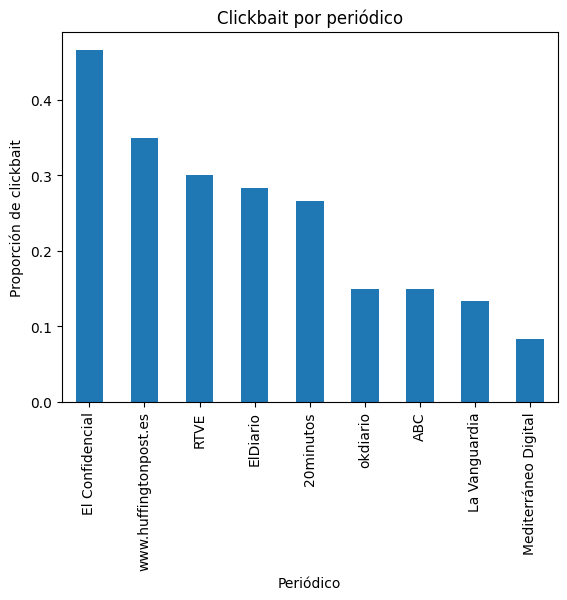

In [9]:
import matplotlib.pyplot as plt

summary["ratio"].plot(kind="bar")
plt.ylabel("Proporción de clickbait")
plt.title("Clickbait por periódico")
plt.show()

In [10]:
df["len_titulo"] = df["Título"].str.len()
df.groupby("cb")["len_titulo"].describe()

,count,mean,std,min,25%,50%,75%,max
cb,,,,,,,,
False,409.0,92.161369,23.856051,23.0,77.0,91.0,108.0,180.0
True,131.0,90.068702,25.810609,27.0,74.5,94.0,109.0,148.0


# Pruebas de métricas

## Longitud del texto


=== LONGITUD EN PALABRAS ===
       count        mean         std   min    25%    50%    75%     max
cb                                                                     
False  409.0  693.036675  831.491217  31.0  322.0  479.0  785.0  9434.0
True   131.0  723.717557  704.935821  11.0  319.0  471.0  812.0  4433.0

=== LONGITUD EN CARACTERES ===
       count         mean          std    min     25%     50%     75%      max
cb                                                                            
False  409.0  4572.048900  6122.078367  184.0  1979.0  2913.0  4943.0  58628.0
True   131.0  4816.343511  5194.012042   68.0  1882.5  2907.0  5043.5  25186.0

=== TEST LONGITUD PALABRAS ===
Statistic: 26969.0
p-value: 0.9083083655876316

=== TEST LONGITUD CARACTERES ===
Statistic: 26864.0
p-value: 0.9620245778869981


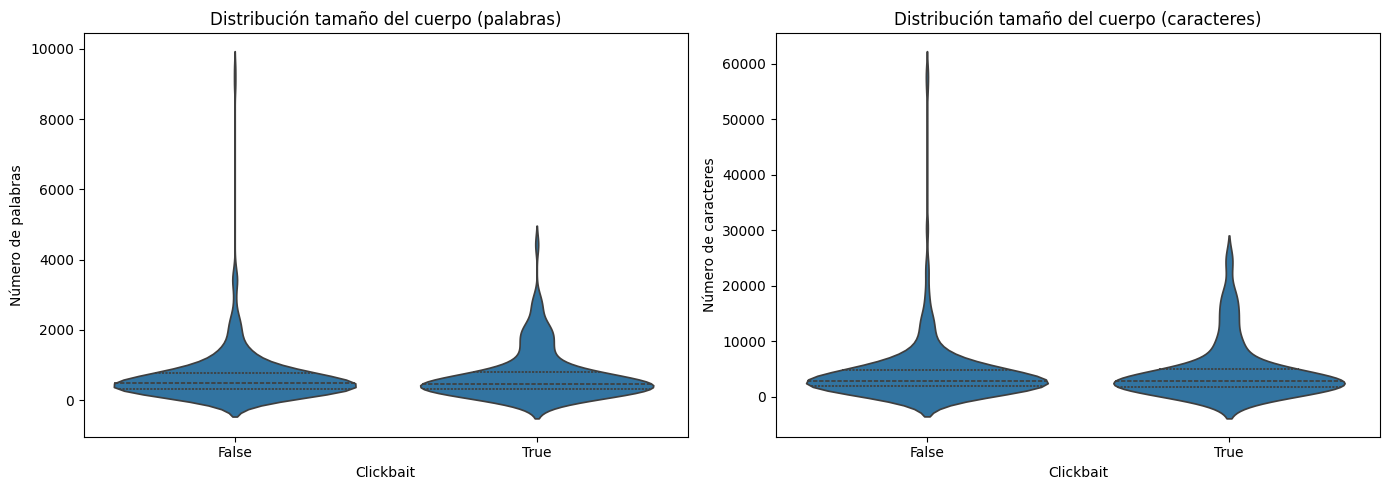

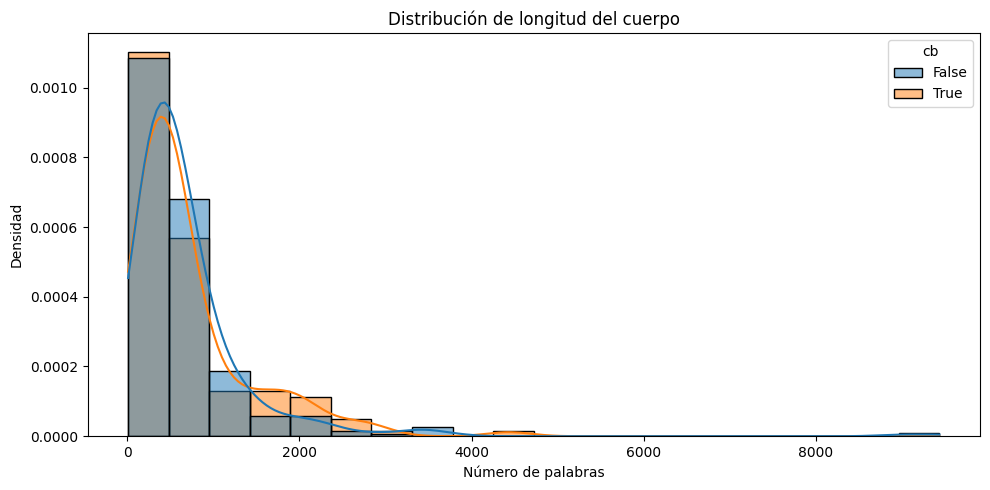

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu


# ============================================================
# TAMAÑO DEL CUERPO
# ============================================================

# número de palabras
df["body_length_words"] = df["Contenido"].apply(
    lambda x: len(str(x).split())
)

# número de caracteres
df["body_length_chars"] = df["Contenido"].apply(
    lambda x: len(str(x))
)


# ============================================================
# RESUMEN ESTADÍSTICO
# ============================================================

print("\n=== LONGITUD EN PALABRAS ===")
print(
    df.groupby("cb")["body_length_words"].describe()
)

print("\n=== LONGITUD EN CARACTERES ===")
print(
    df.groupby("cb")["body_length_chars"].describe()
)


# ============================================================
# TEST ESTADÍSTICO
# ============================================================

click_words = df[df["cb"] == True]["body_length_words"]
noclick_words = df[df["cb"] == False]["body_length_words"]

stat_words, p_words = mannwhitneyu(click_words, noclick_words)

print("\n=== TEST LONGITUD PALABRAS ===")
print("Statistic:", stat_words)
print("p-value:", p_words)


click_chars = df[df["cb"] == True]["body_length_chars"]
noclick_chars = df[df["cb"] == False]["body_length_chars"]

stat_chars, p_chars = mannwhitneyu(click_chars, noclick_chars)

print("\n=== TEST LONGITUD CARACTERES ===")
print("Statistic:", stat_chars)
print("p-value:", p_chars)


# ============================================================
# VIOLIN PLOT
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.violinplot(
    data=df,
    x="cb",
    y="body_length_words",
    inner="quartile",
    ax=axes[0]
)

axes[0].set_title("Distribución tamaño del cuerpo (palabras)")
axes[0].set_xlabel("Clickbait")
axes[0].set_ylabel("Número de palabras")


sns.violinplot(
    data=df,
    x="cb",
    y="body_length_chars",
    inner="quartile",
    ax=axes[1]
)

axes[1].set_title("Distribución tamaño del cuerpo (caracteres)")
axes[1].set_xlabel("Clickbait")
axes[1].set_ylabel("Número de caracteres")


plt.tight_layout()
plt.show()


# ============================================================
# HISTOGRAMA SUPERPUESTO
# ============================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="body_length_words",
    hue="cb",
    kde=True,
    bins=20,
    stat="density",
    common_norm=False,
    alpha=0.5
)

plt.title("Distribución de longitud del cuerpo")
plt.xlabel("Número de palabras")
plt.ylabel("Densidad")

plt.tight_layout()
plt.show()

## Prueba de legibilidad de Flesch-Kincaid

https://es.wikipedia.org/wiki/Prueba_de_legibilidad_de_Flesch-Kincaid

No hay evidencia estadística de que el clickbait y el no-clickbait difieran en complejidad lingüística medida por legibilidad del contenido. Con el título hay mayor diferencia

la señal de diferencia entre clickbait y no-clickbait aparece débilmente, y depende de la métrica usada.

El clickbait en titulares presenta diferencias estadísticamente significativas en métricas de complejidad lexical sensibles (SMOG, Gunning Fog), pero no en métricas globales de legibilidad (Flesch), lo que sugiere que la variación se concentra en cambios locales de densidad léxica más que en estructura sintáctica global.

In [12]:
import spacy
import syllapy
import numpy as np



def contar_silabas(texto):
    palabras = [w for w in texto.split() if w.isalpha()]
    return sum(syllapy.count(w.lower()) for w in palabras)


def flesch_es(texto):
    doc = nlp(texto)

    oraciones = list(doc.sents)
    palabras = [t.text for t in doc if t.is_alpha]

    n_oraciones = max(len(oraciones), 1)
    n_palabras = max(len(palabras), 1)
    n_silabas = contar_silabas(texto)

    score = 206.84 - 0.60*(n_silabas/n_palabras) - 1.02*(n_palabras/n_oraciones)
    return score

df["flesch"] = df["Contenido"].apply(flesch_es)

resumen = df.groupby("Periódico")["flesch"].agg(["mean", "std", "count"]).sort_values("mean")
print(resumen)

/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/syllapy/data_loader.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


                             mean        std  count
Periódico                                          
La Vanguardia          170.147099   8.723835     60
RTVE                   173.060345  10.510835     60
20minutos              173.613351  10.345198     60
El Confidencial        174.634105  11.168880     60
ABC                    176.206212  11.225867     60
Mediterráneo Digital   176.275091   5.435249     60
ElDiario               177.055092   7.032300     60
okdiario               178.736642   6.290926     60
www.huffingtonpost.es  179.396387   6.801769     60


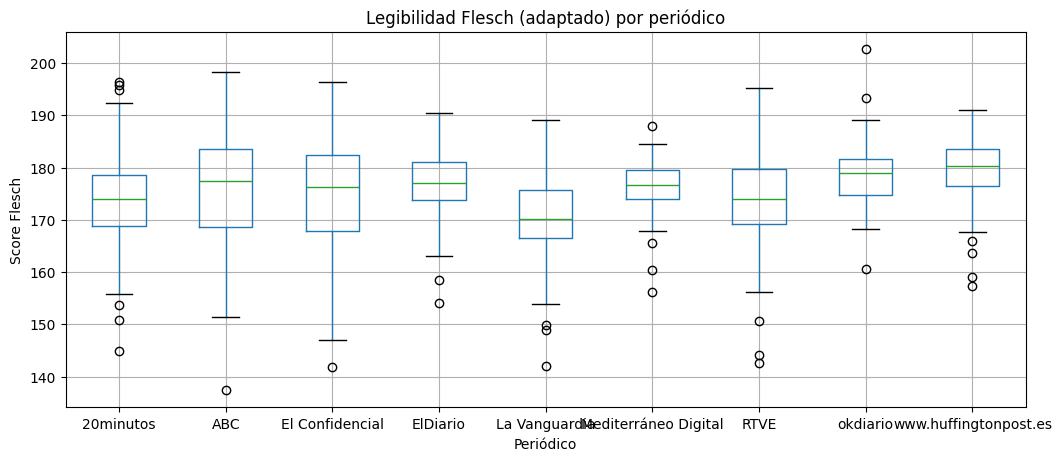

In [13]:
df.boxplot(column="flesch", by="Periódico", figsize=(12,5))
plt.title("Legibilidad Flesch (adaptado) por periódico")
plt.suptitle("")
plt.ylabel("Score Flesch")
plt.show()

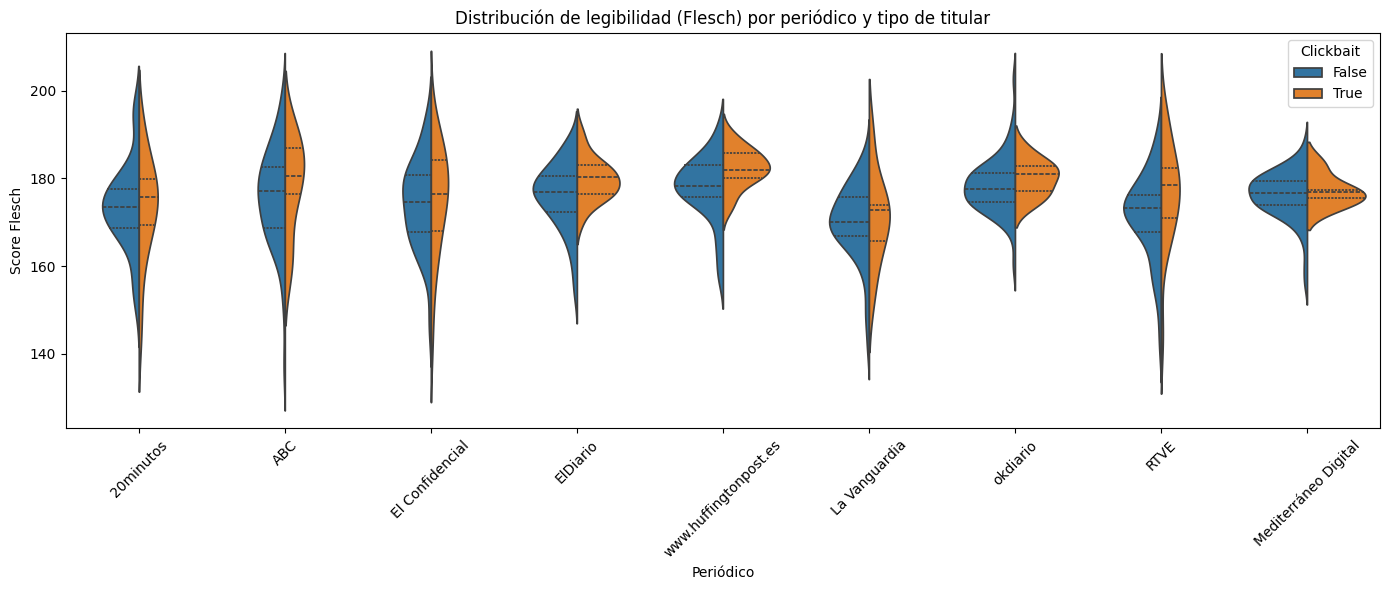

In [14]:

plt.figure(figsize=(14,6))

sns.violinplot(
    data=df,
    x="Periódico",
    y="flesch",
    hue="cb",
    split=True,   # divide clickbait vs no clickbait dentro del mismo violín
    inner="quartile"
)

plt.title("Distribución de legibilidad (Flesch) por periódico y tipo de titular")
plt.xlabel("Periódico")
plt.ylabel("Score Flesch")
plt.xticks(rotation=45)
plt.legend(title="Clickbait")
plt.tight_layout()
plt.show()

In [15]:
clickbait = df[df["cb"] == True]["flesch"].dropna()
noclickbait = df[df["cb"] == False]["flesch"].dropna()

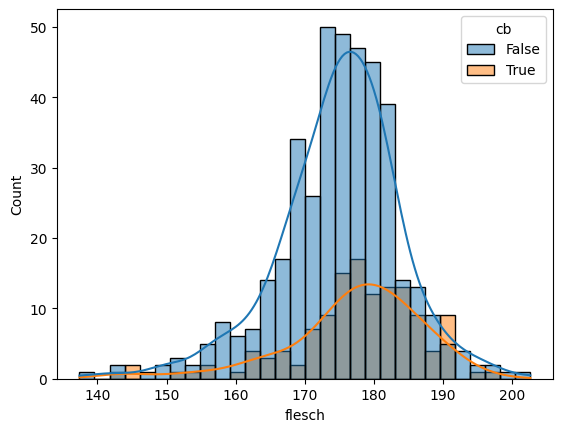

In [16]:
sns.histplot(data=df, x="flesch", hue="cb", kde=True, bins=30)
plt.show()

In [17]:
from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(clickbait, noclickbait)

print("Statistic:", stat)
print("p-value:", p)

Statistic: 32241.0
p-value: 0.00045270647083817654


## Índice de Gunning Fog

In [18]:
import spacy
import syllapy

def gunning_fog(texto):
    doc = nlp(texto)

    palabras = [t.text for t in doc if t.is_alpha]
    oraciones = list(doc.sents)

    n_palabras = len(palabras)
    n_oraciones = max(len(oraciones), 1)

    complejas = sum(1 for w in palabras if syllapy.count(w.lower()) >= 3)

    fog = 0.4 * ((n_palabras / n_oraciones) + 100 * (complejas / n_palabras))
    return fog

df["fog"] = df["Contenido"].apply(gunning_fog)

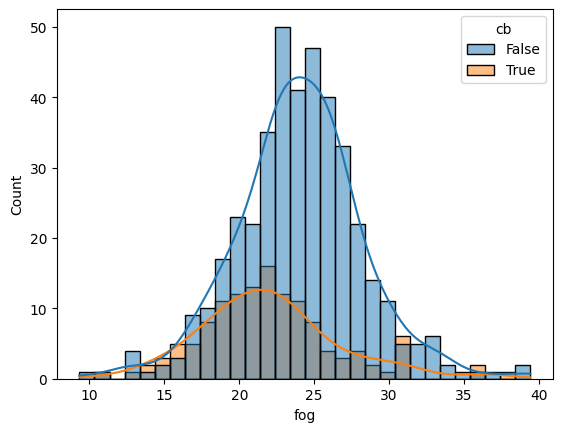

In [19]:
sns.histplot(data=df, x="fog", hue="cb", kde=True, bins=30)
plt.show()

In [20]:
click = df[df["cb"] == True]["fog"]
no_click = df[df["cb"] == False]["fog"]

mannwhitneyu(click, no_click)

MannwhitneyuResult(statistic=np.float64(18378.0), pvalue=np.float64(6.23917496536575e-08))

## Índice de SMOG

In [21]:
import numpy as np

def smog(texto):
    doc = nlp(texto)

    palabras = [t.text for t in doc if t.is_alpha]
    oraciones = list(doc.sents)

    if len(oraciones) == 0:
        return np.nan

    complejas = sum(1 for w in palabras if syllapy.count(w.lower()) >= 3)

    return 1.043 * np.sqrt(complejas * (30 / len(oraciones))) + 3.1291

df["smog"] = df["Título"].apply(smog)

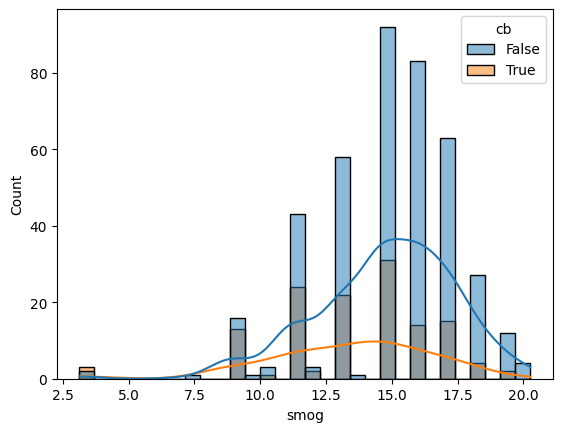

In [22]:
sns.histplot(data=df, x="smog", hue="cb", kde=True, bins=30)
plt.show()

In [23]:
click = df[df["cb"] == True]["smog"]
no_click = df[df["cb"] == False]["smog"]

mannwhitneyu(click, no_click)

MannwhitneyuResult(statistic=np.float64(19915.0), pvalue=np.float64(7.3995905202720735e-06))

## Entropía de Shannon


=== ENTROPÍA CONTENIDO ===
       count      mean       std       min       25%       50%       75%  \
cb                                                                         
False  409.0  7.017836  0.680449  4.215018  6.689287  7.073998  7.432904   
True   131.0  7.140871  0.720278  3.321928  6.840500  7.177501  7.608729   

            max  
cb               
False  8.751069  
True   8.583636  

=== ENTROPÍA CONTENIDO NORMALIZADA ===
       count      mean       std       min       25%       50%       75%  \
cb                                                                         
False  409.0  0.894726  0.031280  0.777869  0.876162  0.895035  0.914835   
True   131.0  0.900573  0.035716  0.810407  0.875479  0.900624  0.926648   

            max  
cb               
False  0.984889  
True   1.000000  

=== ENTROPÍA TÍTULO ===
       count      mean       std       min       25%       50%       75%  \
cb                                                                         
F

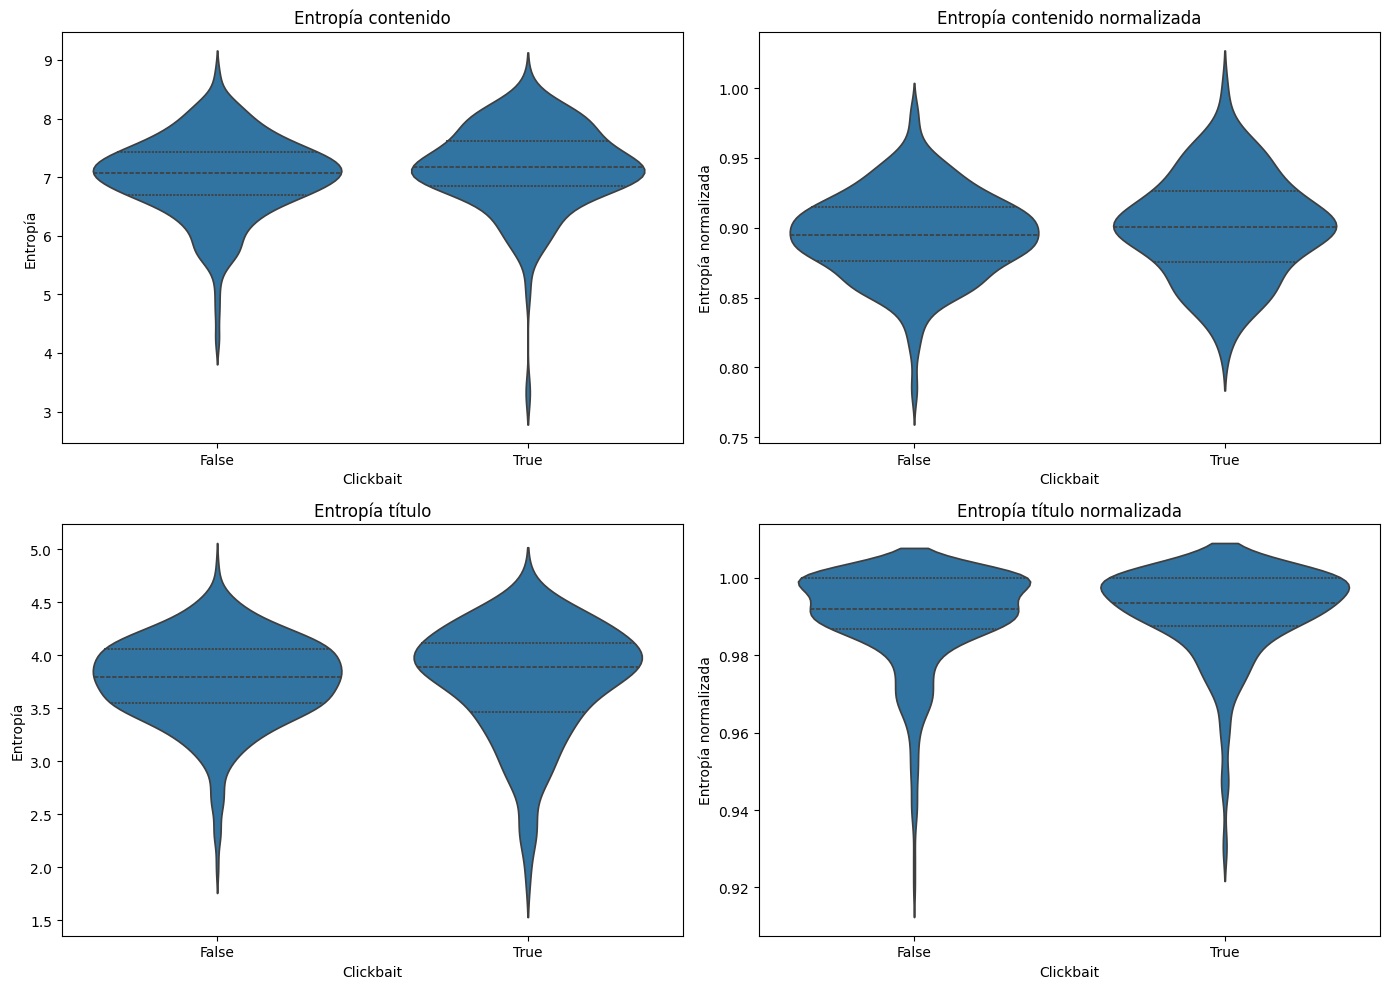

In [24]:
import numpy as np
import pandas as pd
import re

from collections import Counter
from scipy.stats import mannwhitneyu

import seaborn as sns
import matplotlib.pyplot as plt


# ============================================================
# LIMPIEZA DE TEXTO
# ============================================================

def limpiar_texto(texto):

    if not isinstance(texto, str):
        return ""

    texto = texto.lower()

    # eliminar urls
    texto = re.sub(r"http\S+", "", texto)

    # dejar solo letras y espacios
    texto = re.sub(r"[^a-záéíóúñü\s]", " ", texto)

    # eliminar espacios múltiples
    texto = re.sub(r"\s+", " ", texto).strip()

    return texto


# ============================================================
# ENTROPÍA DE SHANNON
# ============================================================

def shannon_entropy(texto):

    texto = limpiar_texto(texto)

    palabras = texto.split()

    if len(palabras) == 0:
        return np.nan

    freqs = Counter(palabras)

    probs = np.array(list(freqs.values())) / len(palabras)

    entropy = -np.sum(probs * np.log2(probs))

    return entropy


# ============================================================
# ENTROPÍA NORMALIZADA
# ============================================================

def normalized_entropy(texto):

    texto = limpiar_texto(texto)

    palabras = texto.split()

    if len(palabras) < 2:
        return np.nan

    freqs = Counter(palabras)

    probs = np.array(list(freqs.values())) / len(palabras)

    H = -np.sum(probs * np.log2(probs))

    Hmax = np.log2(len(freqs))

    if Hmax == 0:
        return 0

    return H / Hmax


# ============================================================
# CALCULAR ENTROPÍAS
# ============================================================

# contenido
df["entropy_content"] = df["Contenido"].apply(shannon_entropy)

# contenido normalizado
df["entropy_content_norm"] = df["Contenido"].apply(normalized_entropy)

# títulos
df["entropy_title"] = df["Título"].apply(shannon_entropy)

# títulos normalizados
df["entropy_title_norm"] = df["Título"].apply(normalized_entropy)


# ============================================================
# RESUMEN ESTADÍSTICO
# ============================================================

print("\n=== ENTROPÍA CONTENIDO ===")
print(df.groupby("cb")["entropy_content"].describe())

print("\n=== ENTROPÍA CONTENIDO NORMALIZADA ===")
print(df.groupby("cb")["entropy_content_norm"].describe())

print("\n=== ENTROPÍA TÍTULO ===")
print(df.groupby("cb")["entropy_title"].describe())

print("\n=== ENTROPÍA TÍTULO NORMALIZADA ===")
print(df.groupby("cb")["entropy_title_norm"].describe())


# ============================================================
# TEST MANN-WHITNEY
# ============================================================

def mannwhitney_test(columna):

    click = df[df["cb"] == True][columna].dropna()
    noclick = df[df["cb"] == False][columna].dropna()

    stat, p = mannwhitneyu(click, noclick)

    print(f"\n--- {columna} ---")
    print("Statistic:", stat)
    print("p-value:", p)


mannwhitney_test("entropy_content")
mannwhitney_test("entropy_content_norm")
mannwhitney_test("entropy_title")
mannwhitney_test("entropy_title_norm")


# ============================================================
# VIOLIN PLOTS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.violinplot(
    data=df,
    x="cb",
    y="entropy_content",
    inner="quartile",
    ax=axes[0,0]
)

axes[0,0].set_title("Entropía contenido")
axes[0,0].set_xlabel("Clickbait")
axes[0,0].set_ylabel("Entropía")


sns.violinplot(
    data=df,
    x="cb",
    y="entropy_content_norm",
    inner="quartile",
    ax=axes[0,1]
)

axes[0,1].set_title("Entropía contenido normalizada")
axes[0,1].set_xlabel("Clickbait")
axes[0,1].set_ylabel("Entropía normalizada")


sns.violinplot(
    data=df,
    x="cb",
    y="entropy_title",
    inner="quartile",
    ax=axes[1,0]
)

axes[1,0].set_title("Entropía título")
axes[1,0].set_xlabel("Clickbait")
axes[1,0].set_ylabel("Entropía")


sns.violinplot(
    data=df,
    x="cb",
    y="entropy_title_norm",
    inner="quartile",
    ax=axes[1,1]
)

axes[1,1].set_title("Entropía título normalizada")
axes[1,1].set_xlabel("Clickbait")
axes[1,1].set_ylabel("Entropía normalizada")


plt.tight_layout()
plt.show()

## LSA

In [25]:
# corpus=cargar_datos(1)
similitudes,tfidf_lsa=LSA_vectors(corpus,min_df=2)


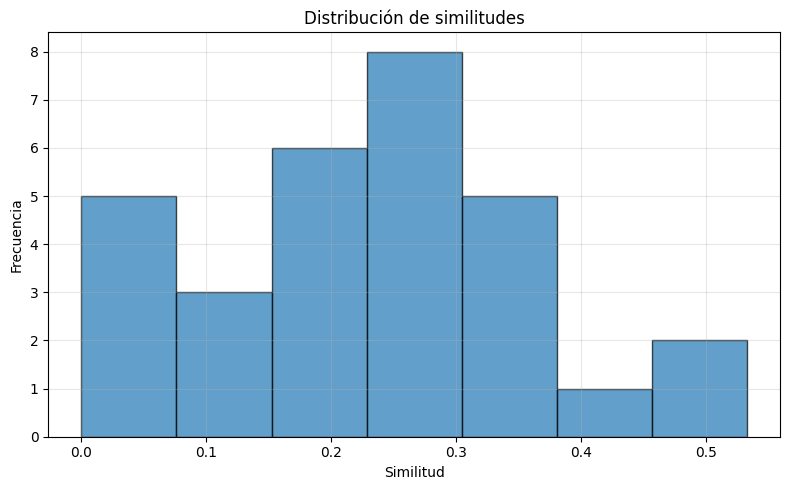

In [26]:
plt.figure(figsize=(8, 5))

plt.hist(
    similitudes,
    bins=7,          # Número de bins
    edgecolor='black',
    alpha=0.7
)

plt.xlabel("Similitud")
plt.ylabel("Frecuencia")
plt.title("Distribución de similitudes")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Embeding semántico

Aplicar:Crear un vector adicional de features de decticos, puntuación, superlativos. Si el embeding cae en una zona del espacio muy cargada de adjetivos pero el cuerpo está en una zona neutral, esa diferencia puede ser indicios de clickbait.

Título: Una corte de apelaciones en Nueva York falla en contra de la política de detención de migrantes de Trump


Fragmentos:
  Fragmento 1: Un nuevo revés para el presidente Donald Trump en Nueva York. Un tribunal de apelaciones
  Fragmento 2: de este estado ha fallado este martes en contra de la política del republicano que
  Fragmento 3: instruye a las autoridades a detener -sin posibilidad de fianza- a los migrantes que captura
  Fragmento 4: en el país.De manera unánime, los tres jueces del tribunal del Segundo Circuito, en Nueva
  Fragmento 5: York, han rechazado la interpretación que el Gobierno le está dando a la ley de
  Fragmento 6: migración, al forzar a las personas que son arrestadas por las autoridades migratorias a permanecer
  Fragmento 7: detenidas mientras se resuelven sus casos, procesos que pueden durar meses o incluso años.En el
  Fragmento 8: fallo, los jueces han dicho que, aceptar esa política, supondría "el mandato más amplio de
  Fragmento 9: detención masiva

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00,  2.30it/s]
/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


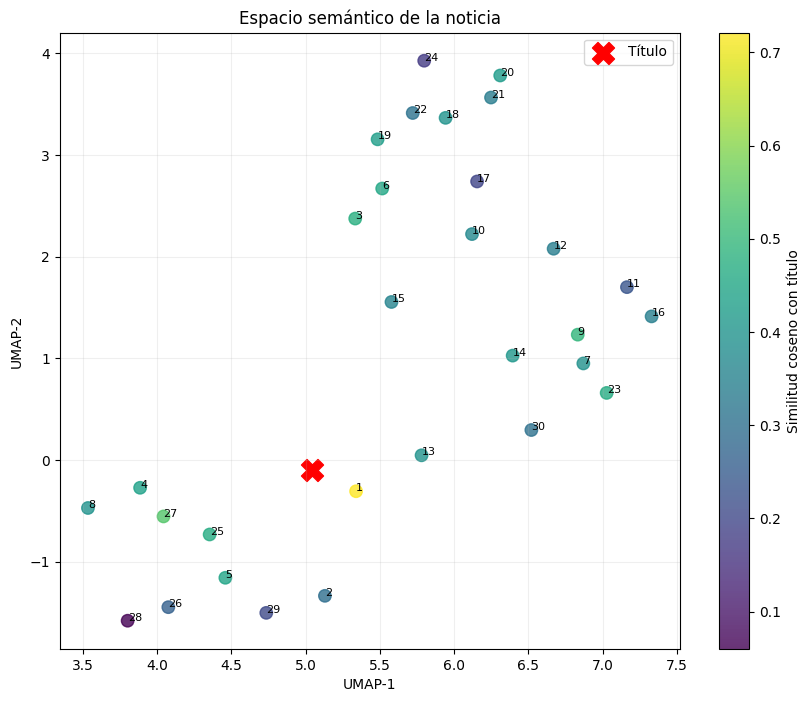

In [27]:
# corpus=cargar_datos(1)
titulo, fragmentos_contenido,noticia=cargar_datos(noticias, n_noticia=5, print_info=True)
corpus = [titulo] + fragmentos_contenido

similarities,embeddings=embedding_sentence_transformers(corpus,embedding_model)
embedding_2d=embedding_umap(similarities,embeddings, plot=True)

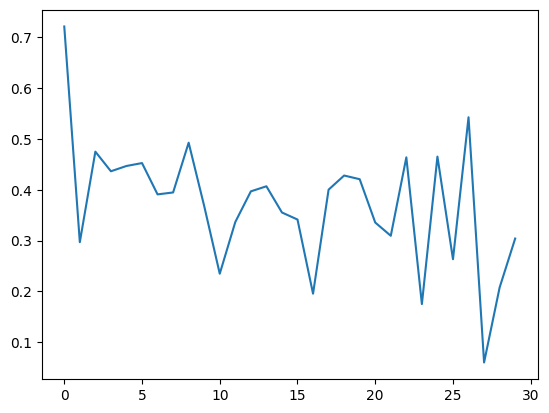

In [28]:
plt.plot(similarities)

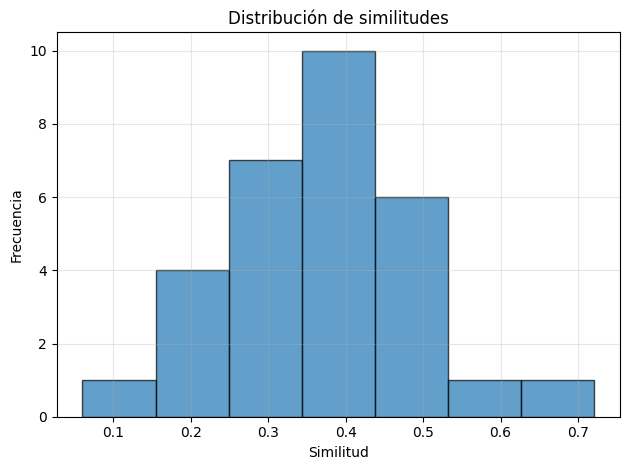

In [29]:
plt.hist(
    similarities,
    bins=7,          # Número de bins
    edgecolor='black',
    alpha=0.7
)

plt.xlabel("Similitud")
plt.ylabel("Frecuencia")
plt.title("Distribución de similitudes")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Embeding semántico + Features lingüísticos

Se ha decidido añadir un feature lingüístico con el objetivo de comparar el lenguaje emotivo/directo entre el título y el cuerpo de la noticia. Estos features capturan ese patrón: títulos con muchos deícticos y puntuación atraen pero el contenido es neutral.
Contadores de deícticos (yo, tú, él...), puntuación (!, ?, ¡¿) y superlativos (muy, increíblemente, -ísimo).

- Para que se puedan comparar el deícticos, puntuación y los superlativos se ha decidido normalizar con StandardScaler

- Se calcula el score como:
$$score=(1-similitud)\cdot diferencia_lingüística$$
De tal forma que si la similitud es 1 en el espacio embebido será 0.
Cuánto más sea la diferencia entre el título y el contenido mayor será el diferencia_lingüística.

De tal forma que solo será alto si ambas condiciones ocurren.

Batches: 100%|██████████| 1/1 [00:00<00:00,  6.30it/s]
/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


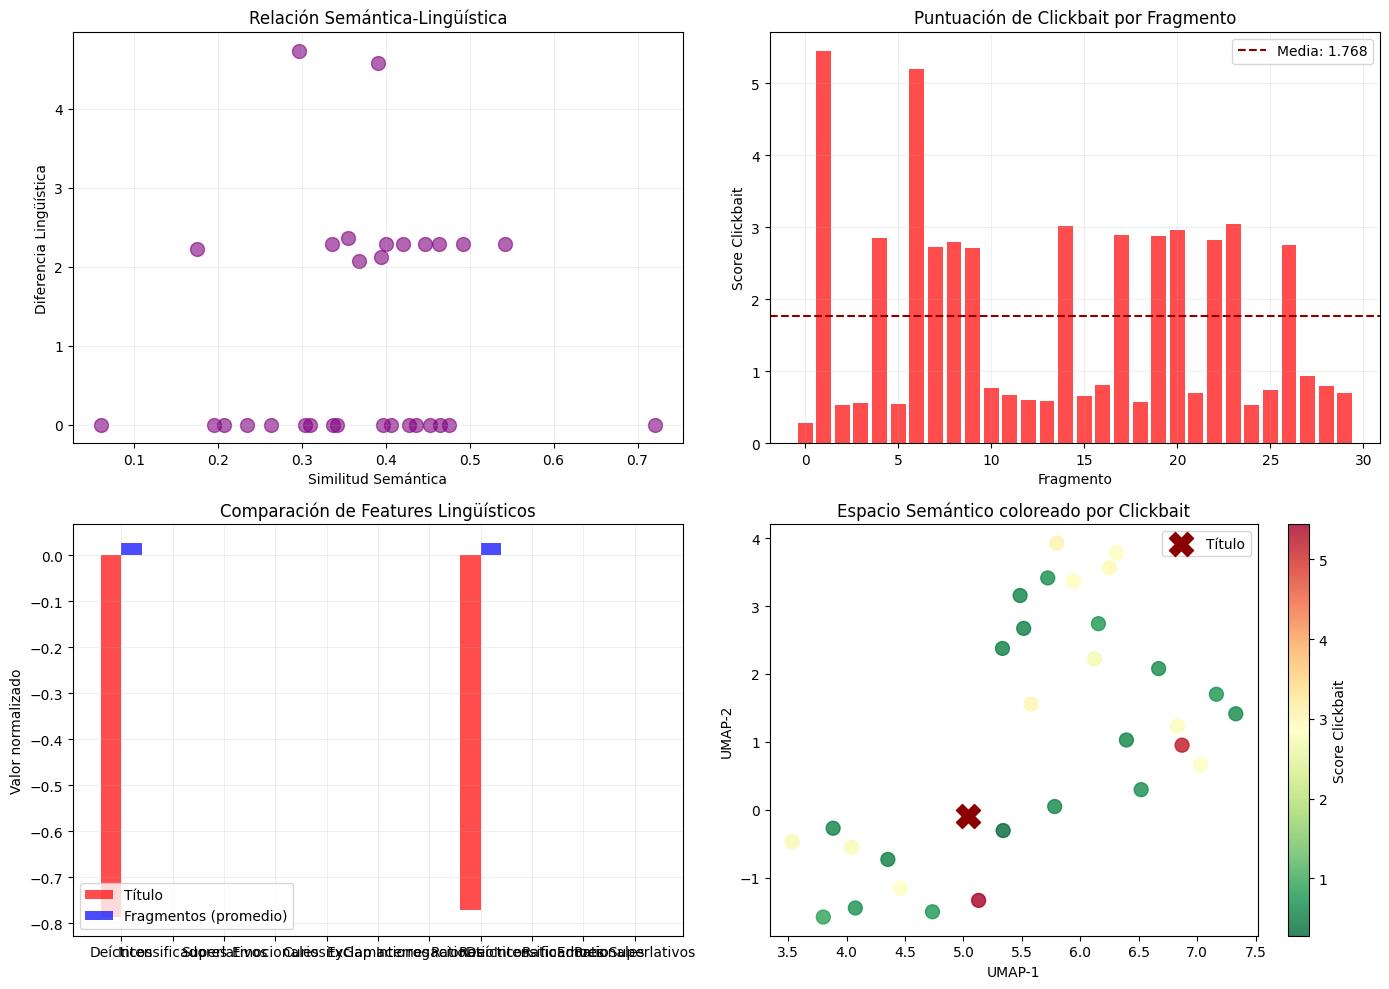

In [30]:

def analizar_clickbait(noticias, n_noticia, embedding_model, plot=False):
    """
    Combina embeddings semánticos con features lingüísticos para detectar clickbait
    input: noticias (list), n_noticia (int), plot (bool)
    output: score_medio (float), análisis (dict)
    """
    # 1. Cargar datos
    
    titulo, fragmentos, noticia = cargar_datos(noticias, n_noticia)
    periodico=noticia["Periódico"]
    categoria=noticia["Categoría"]
    contenido=noticia["Contenido"]
    link=noticia["Link"]
    corpus = [titulo] + fragmentos
    
    # 2. Extraer features lingüísticos
    features_ling = extraer_features_linguisticos(corpus)
    diferencias_ling, (titulo_norm, fragmentos_norm) = calcular_diferencia_features(corpus)
    
    # 3. Embeddings semánticos
    similarities, embeddings = embedding_sentence_transformers(corpus,embedding_model)
    embedding_2d = embedding_umap(similarities, embeddings, plot=False)


    # 3.1 Information structure features ---------------------------------- NUEVO
    similarities_array = np.array(similarities)

    # posición del máximo (relevancia tardía)
    argmax_relevance = np.argmax(similarities_array)

    # normalizado (0 = inicio, 1 = final)
    position_relevance = argmax_relevance / (len(similarities_array) - 1 + 1e-8)

    # information delay (qué tan tarde aparece la info relevante)
    information_delay = position_relevance 
    split = len(similarities_array) // 2

    early_mean = np.mean(similarities_array[:split])
    late_mean = np.mean(similarities_array[split:])

    early_late_ratio = early_mean / (late_mean + 1e-8)
    #------------------------------------------------------------------------------ NUEVO
    # 4. Normalizar features lingüísticos
    scaler = StandardScaler()
    features_norm = scaler.fit_transform(features_ling)
    titulo_features = features_norm[0]
    fragmentos_features = features_norm[1:]
    
    # 5. Distancia en espacio UMAP
    titulo_2d = embedding_2d[0]
    fragmentos_2d = embedding_2d[1:]
    dist_semantica = np.linalg.norm(fragmentos_2d - titulo_2d, axis=1)
    
    # 6. SCORE CLICKBAIT: (1 - similitud semántica) × distancia lingüística

    score_clickbait = (1 - similarities)+diferencias_ling


    score_medio = np.mean(score_clickbait)
    
    analisis = {
        'titulo': titulo,
        'contenido': contenido,
        'periodico': periodico,
        'categoria': categoria,
        'link': link,
        'score_clickbait': score_clickbait,
        'score_medio': score_medio,
        'similitud_semantica': similarities,
        'diferencias_linguisticas': diferencias_ling,
        'dist_semantica': dist_semantica,
        'features_titulo': titulo_features,
        'features_fragmentos': fragmentos_features,
        'information_delay': information_delay,
        'position_relevance': position_relevance,
        'early_late_ratio': early_late_ratio,
        'argmax_relevance': argmax_relevance,

    }
    
    if plot:
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        
        # Similitud semántica vs distancia lingüística
        axes[0, 0].scatter(similarities, diferencias_ling, s=100, alpha=0.6, color='purple')
        axes[0, 0].set_xlabel('Similitud Semántica')
        axes[0, 0].set_ylabel('Diferencia Lingüística')
        axes[0, 0].set_title('Relación Semántica-Lingüística')
        axes[0, 0].grid(alpha=0.2)
        
        # Score de clickbait por fragmento
        axes[0, 1].bar(range(len(score_clickbait)), score_clickbait, color='red', alpha=0.7)
        axes[0, 1].axhline(y=score_medio, color='darkred', linestyle='--', label=f'Media: {score_medio:.3f}')
        axes[0, 1].set_xlabel('Fragmento')
        axes[0, 1].set_ylabel('Score Clickbait')
        axes[0, 1].set_title('Puntuación de Clickbait por Fragmento')
        axes[0, 1].legend()
        axes[0, 1].grid(alpha=0.2)
        
        # Features: título vs fragmentos
        features_names = [
            'Deícticos',
            'Intensificadores',
            'Superlativos',
            'Emocionales',
            'CuriosityGap',
            'Exclamaciones',
            'Interrogaciones',
            #'PuntosSuspensivos',
            #'Mayúsculas',
            #'Números',
            'RatioDeícticos',
            'RatioIntensificadores',
            'RatioEmocionales',
            'RatioSuperlativos'
        ]
        x_pos = np.arange(len(features_names))
        titulo_vals = titulo_features
        fragmentos_vals = np.mean(fragmentos_features, axis=0)
        
        axes[1, 0].bar(x_pos - 0.2, titulo_vals, 0.4, label='Título', color='red', alpha=0.7)
        axes[1, 0].bar(x_pos + 0.2, fragmentos_vals, 0.4, label='Fragmentos (promedio)', color='blue', alpha=0.7)
        axes[1, 0].set_ylabel('Valor normalizado')
        axes[1, 0].set_title('Comparación de Features Lingüísticos')
        axes[1, 0].set_xticks(x_pos)
        axes[1, 0].set_xticklabels(features_names)
        axes[1, 0].legend()
        axes[1, 0].grid(alpha=0.2)
        
        # Espacio UMAP coloreado por score clickbait
        x = embedding_2d[:, 0]
        y = embedding_2d[:, 1]
        scatter = axes[1, 1].scatter(x[1:], y[1:], c=score_clickbait, cmap='RdYlGn_r', s=100, alpha=0.8)
        axes[1, 1].scatter(x[0], y[0], color='darkred', s=300, marker='X', label='Título')
        axes[1, 1].set_xlabel('UMAP-1')
        axes[1, 1].set_ylabel('UMAP-2')
        axes[1, 1].set_title('Espacio Semántico coloreado por Clickbait')
        axes[1, 1].legend()
        plt.colorbar(scatter, ax=axes[1, 1], label='Score Clickbait')
        
        plt.tight_layout()
        plt.show()
    
    return score_medio, analisis

score, datos = analizar_clickbait(noticias, 5, embedding_model, plot=True)

In [31]:
# ESTE CÓDIGO NO ESTÁ BIEN MIRADO, SOLO ERAP ARA SACAR RESULTADOS RÁPIDOS DE LO ANTERIOR


def procesar_todas_noticias(noticias):
    """
    Procesa todas las noticias y calcula score de clickbait
    input: noticias (list)
    output: dataframe con scores y metadatos
    """
    resultados = []
    
    for n in range(len(noticias)):
        try:
            score_medio, analisis = analizar_clickbait(noticias, n, embedding_model, plot=False)
            
            noticia = noticias[n]
            resultados.append({
                'id_noticia': n,
                'titulo': noticia.get('Título', ''),
                'contenido': noticia.get('Contenido', ''),
                'categoria': noticia.get('Categoría', ''),
                'periodico': noticia.get('Periódico', ''),
                'clickbait': noticia.get('cb', False),
                'score_clickbait': score_medio,
                'similitud_media': np.mean(analisis['similitud_semantica']),
                'diferencia_ling_media': np.mean(analisis['diferencias_linguisticas']),
                'deicticos_titulo': analisis['features_titulo'][0],
                'puntuacion_titulo': analisis['features_titulo'][1],
                'superlativos_titulo': analisis['features_titulo'][2],
                'information_delay': analisis['information_delay'],
                'position_relevance': analisis['position_relevance'],
                'early_late_ratio': analisis['early_late_ratio'],
                'argmax_relevance': analisis['argmax_relevance'],

            })
            
            print(f"✓ Noticia {n}/{len(noticias)-1}")
        
        except Exception as e:
            print(f"✗ Error en noticia {n}: {e}")
    
    df = pd.DataFrame(resultados)
    return df


def visualizar_resultados_clickbait(df):
    """
    Visualiza histogramas y estadísticas de clickbait
    input: df (pandas DataFrame)
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Histograma de scores
    axes[0, 0].hist(df['score_clickbait'], bins=30, color='red', alpha=0.7, edgecolor='black')
    axes[0, 0].axvline(df['score_clickbait'].mean(), color='darkred', linestyle='--', 
                       label=f'Media: {df["score_clickbait"].mean():.3f}')
    axes[0, 0].axvline(df['score_clickbait'].median(), color='orange', linestyle='--', 
                       label=f'Mediana: {df["score_clickbait"].median():.3f}')
    axes[0, 0].set_xlabel('Score Clickbait')
    axes[0, 0].set_ylabel('Frecuencia')
    axes[0, 0].set_title('Distribución de Scores de Clickbait')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.2)
    
    # 2. Score por categoría
    df.boxplot(column='score_clickbait', by='categoria', ax=axes[0, 1])
    axes[0, 1].set_title('Score de Clickbait por Categoría')
    axes[0, 1].set_xlabel('Categoría')
    axes[0, 1].set_ylabel('Score Clickbait')
    plt.sca(axes[0, 1])
    plt.xticks(rotation=45, ha='right')
    
    # 3. Score por periódico
    df.boxplot(column='score_clickbait', by='periodico', ax=axes[1, 0])
    axes[1, 0].set_title('Score de Clickbait por Periódico')
    axes[1, 0].set_xlabel('Periódico')
    axes[1, 0].set_ylabel('Score Clickbait')
    plt.sca(axes[1, 0])
    plt.xticks(rotation=45, ha='right')
    
    # 4. Scatter: similitud vs diferencia lingüística
    scatter = axes[1, 1].scatter(df['similitud_media'], df['diferencia_ling_media'], 
                                c=df['score_clickbait'], cmap='RdYlGn_r', s=100, alpha=0.6)
    axes[1, 1].set_xlabel('Similitud Semántica Media')
    axes[1, 1].set_ylabel('Diferencia Lingüística Media')
    axes[1, 1].set_title('Relación Semántica-Lingüística')
    plt.colorbar(scatter, ax=axes[1, 1], label='Score Clickbait')
    axes[1, 1].grid(alpha=0.2)
    
    plt.tight_layout()
    plt.show()


def estadisticas_clickbait(df):
    """
    Imprime estadísticas generales
    input: df (pandas DataFrame)
    """
    print("\n" + "="*80)
    print("ESTADÍSTICAS DE CLICKBAIT")
    print("="*80)
    
    print(f"\n📊 GENERAL:")
    print(f"  • Total noticias: {len(df)}")
    print(f"  • Score medio: {df['score_clickbait'].mean():.3f}")
    print(f"  • Score máximo: {df['score_clickbait'].max():.3f}")
    print(f"  • Score mínimo: {df['score_clickbait'].min():.3f}")
    print(f"  • Desviación estándar: {df['score_clickbait'].std():.3f}")
    
    print(f"\n🏆 NOTICIAS CON MAYOR CLICKBAIT:")
    top_5 = df.nlargest(5, 'score_clickbait')[['id_noticia', 'titulo', 'categoria', 'score_clickbait']]
    for idx, row in top_5.iterrows():
        print(f"  {row['id_noticia']}. [{row['categoria']}] {row['titulo'][:60]}... ({row['score_clickbait']:.3f})")
    
    print(f"\n📁 POR CATEGORÍA:")
    for cat in df['categoria'].unique():
        df_cat = df[df['categoria'] == cat]
        print(f"  • {cat}: {len(df_cat)} noticias, media={df_cat['score_clickbait'].mean():.3f}")
    
    print(f"\n📰 POR PERIÓDICO:")
    for per in df['periodico'].unique():
        df_per = df[df['periodico'] == per]
        print(f"  • {per}: {len(df_per)} noticias, media={df_per['score_clickbait'].mean():.3f}")


# USO
df_resultados = procesar_todas_noticias(noticias)
estadisticas_clickbait(df_resultados)
# Guardar resultados
df_resultados.to_csv('resultados_clickbait.csv', index=False)

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches: 100%|██████████| 2/2 [00:00<00:00, 13.07it/s]
/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✓ Noticia 0/539


Batches: 100%|██████████| 2/2 [00:00<00:00, 18.52it/s]

✓ Noticia 1/539


...

✓ Noticia 537/539


Batches: 100%|██████████| 1/1 [00:00<00:00, 15.07it/s]
/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✓ Noticia 538/539


Batches: 100%|██████████| 1/1 [00:00<00:00, 20.28it/s]
/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✓ Noticia 539/539

ESTADÍSTICAS DE CLICKBAIT

📊 GENERAL:
  • Total noticias: 539
  • Score medio: 2.466
  • Score máximo: 10.414
  • Score mínimo: 0.444
  • Desviación estándar: 1.159

🏆 NOTICIAS CON MAYOR CLICKBAIT:
  275. [Nacional] Carlos Cuerpo: "Aspiro a cubrir ese espacio de mayor sosiego... (10.414)
  295. [Cultura] Ayuso vuelve a España y un catedrático de Historia le dedica... (9.886)
  386. [Nacional] Despliegue policial en un centro de La Línea tras la brutal ... (9.110)
  147. [Nacional] ¿Por qué Majadahonda está tan cerca y Getafe tan lejos?... (8.759)
  360. [Internacional] El vicepresidente Vance, el primero en ser rescatado del tir... (7.988)

📁 POR CATEGORÍA:
  • Internacional: 190 noticias, media=2.353
  • Nacional: 190 noticias, media=2.434
  • Cultura: 159 noticias, media=2.641

📰 POR PERIÓDICO:
  • 20minutos: 60 noticias, media=2.570
  • ABC: 60 noticias, media=2.444
  • El Confidencial: 60 noticias, media=2.588
  • ElDiario: 60 noticias, media=2.566
  • www.huffin

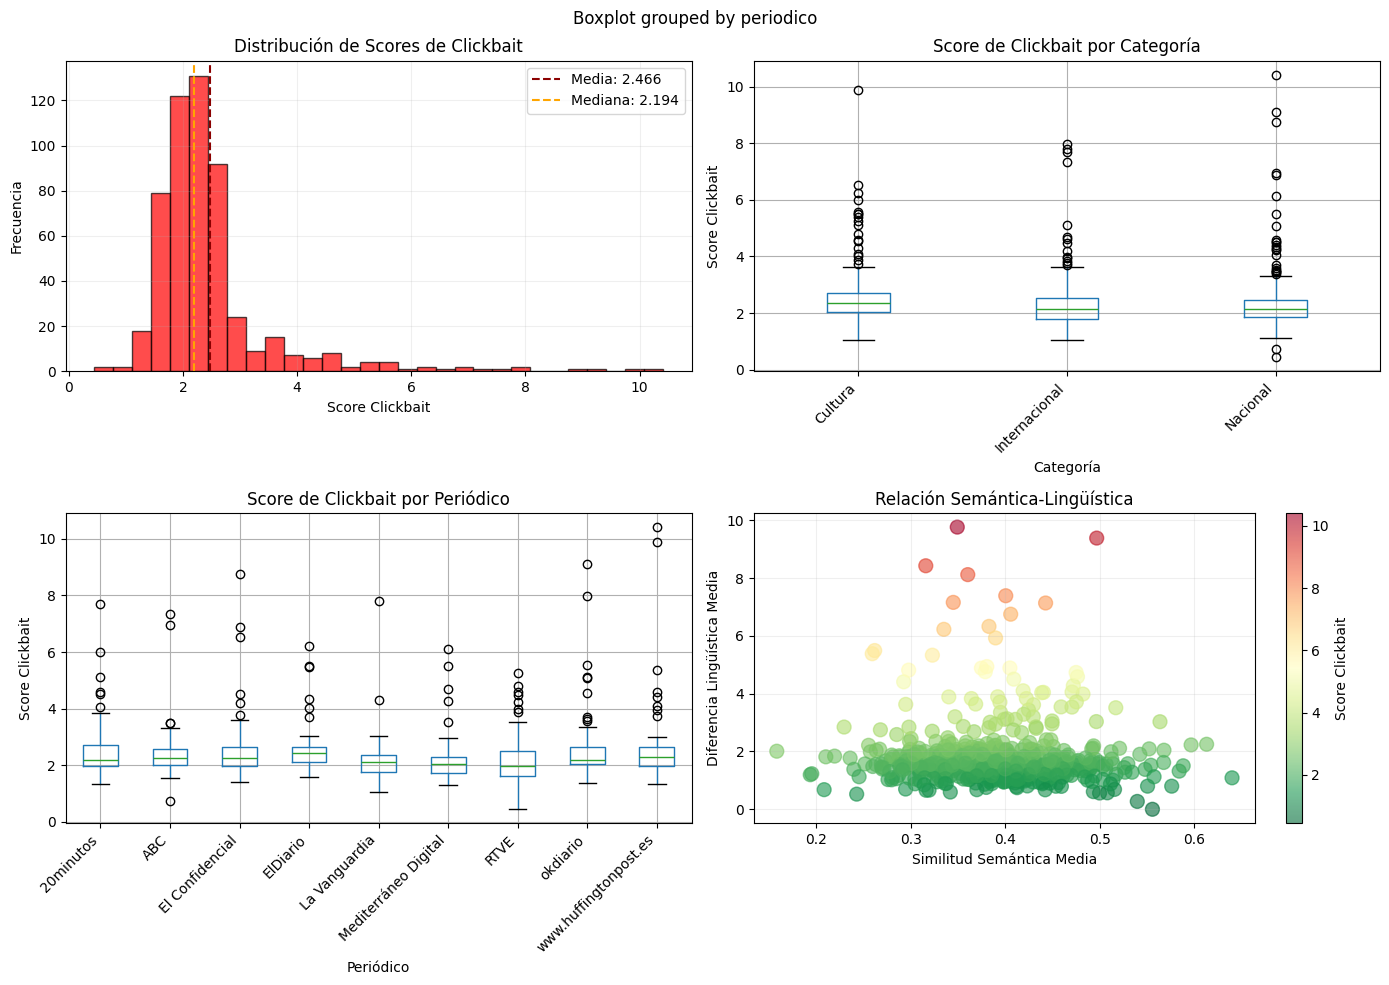

In [32]:
visualizar_resultados_clickbait(df_resultados)

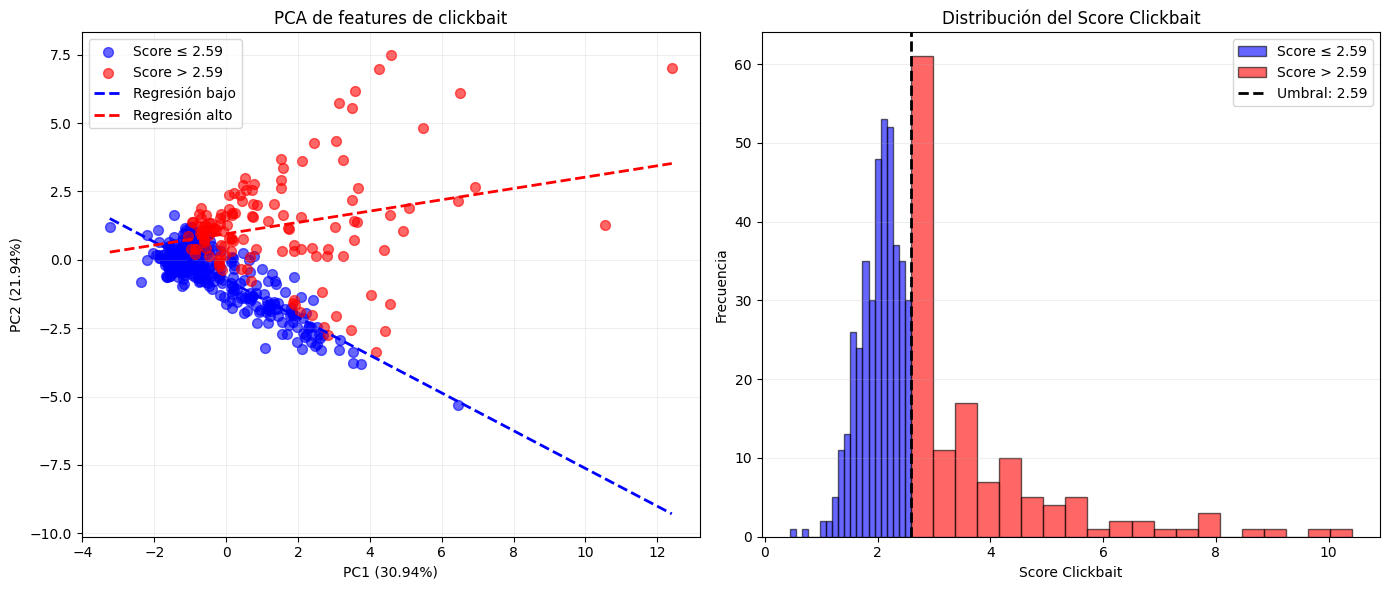

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

df = pd.read_csv("resultados_clickbait.csv")

features = [
    "score_clickbait",
    "similitud_media",
    "diferencia_ling_media",
    "deicticos_titulo",
    "puntuacion_titulo",
    "superlativos_titulo",
    "information_delay",
    "position_relevance",
    "early_late_ratio",
    "argmax_relevance",
]

X = df[features].fillna(0).values
y = df["clickbait"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Umbral
threshold = df["score_clickbait"].median()+0.4
bajo = df["score_clickbait"] <= threshold
alto = df["score_clickbait"] > threshold

# Regresiones lineales
reg_bajo = LinearRegression()
reg_bajo.fit(X_pca[bajo, 0].reshape(-1, 1), X_pca[bajo, 1])

reg_alto = LinearRegression()
reg_alto.fit(X_pca[alto, 0].reshape(-1, 1), X_pca[alto, 1])

x_line = np.linspace(X_pca[:, 0].min(), X_pca[:, 0].max(), 100)

fig = plt.figure(figsize=(14, 6))

# PCA
ax1 = plt.subplot(1, 2, 1)
ax1.scatter(X_pca[bajo, 0], X_pca[bajo, 1], label=f"Score ≤ {threshold:.2f}", alpha=0.6, s=50, color="blue")
ax1.scatter(X_pca[alto, 0], X_pca[alto, 1], label=f"Score > {threshold:.2f}", alpha=0.6, s=50, color="red")
ax1.plot(x_line, reg_bajo.predict(x_line.reshape(-1, 1)), "b--", linewidth=2, label="Regresión bajo")
ax1.plot(x_line, reg_alto.predict(x_line.reshape(-1, 1)), "r--", linewidth=2, label="Regresión alto")
ax1.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%})")
ax1.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%})")
ax1.set_title("PCA de features de clickbait")
ax1.legend()
ax1.grid(alpha=0.2)

# Histograma
ax2 = plt.subplot(1, 2, 2)
ax2.hist(df[bajo]["score_clickbait"], bins=20, alpha=0.6, label=f"Score ≤ {threshold:.2f}", color="blue", edgecolor="black")
ax2.hist(df[alto]["score_clickbait"], bins=20, alpha=0.6, label=f"Score > {threshold:.2f}", color="red", edgecolor="black")
ax2.axvline(threshold, color="black", linestyle="--", linewidth=2, label=f"Umbral: {threshold:.2f}")
ax2.set_xlabel("Score Clickbait")
ax2.set_ylabel("Frecuencia")
ax2.set_title("Distribución del Score Clickbait")
ax2.legend()
ax2.grid(alpha=0.2, axis="y")

plt.tight_layout()
plt.show()

In [34]:
import plotly.express as px
import pandas as pd

# 1. Preparamos un DataFrame temporal para Plotly
# Esto facilita que Plotly asocie cada punto con su título y score
df_plot = pd.DataFrame({
    'Dim 1': X_pca[:, 0], # O X_umap[:, 0]
    'Dim 2': X_pca[:, 1], # O X_umap[:, 1]
    'Score': df['score_clickbait'],
    'Es Clickbait': df['clickbait'].astype(str), # Convertimos a texto para la leyenda
    'Titulo': df['titulo']
})

# 2. Creamos el gráfico
fig = px.scatter(
    df_plot, 
    x='Dim 1', 
    y='Dim 2', 
    color='Score',           # Gradiente de color
    symbol='Es Clickbait',    # Forma diferente (Círculo/Diamante/etc)
    hover_name='Titulo',      # <--- ESTO hará que se vea el título al pasar el ratón
    hover_data={'Score': ':.2f', 'Es Clickbait': True, 'Dim 1': False, 'Dim 2': False},
    color_continuous_scale='plasma',
    title="Análisis Interactivo de Clickbait",
    labels={'Es Clickbait': '¿Es Clickbait?'}
)

# Ajustes de estilo
fig.update_traces(marker=dict(size=10, line=dict(width=0.5, color='White')))
fig.update_layout(template='plotly_white')

fig.show()

/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


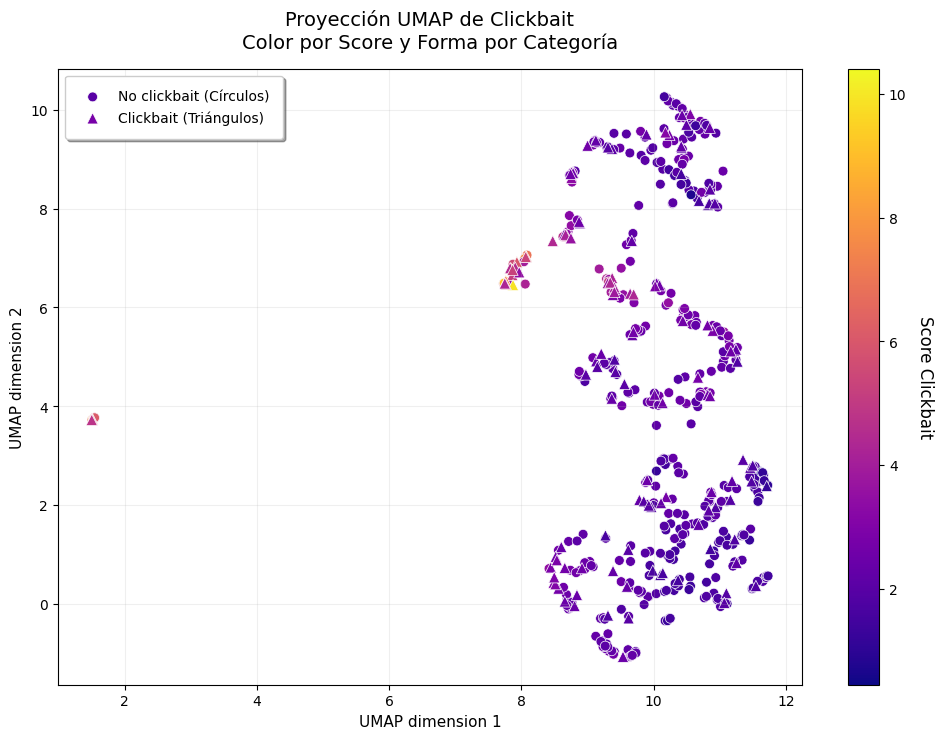

In [35]:
reducer = UMAP(
    n_neighbors=15,      # Valor bajo para resaltar grupos locales
    min_dist=0.01,       # Valor muy bajo para compactar los puntos
    n_components=2,
    metric="cosine",     # Excelente para features de texto/scores
    learning_rate=0.01,   # Ayuda a que la optimización sea más agresiva
    random_state=37
)

X_umap = reducer.fit_transform(X_scaled)
import matplotlib.pyplot as plt

# 1. Extraemos los datos necesarios
# Asegúrate de haber ejecutado antes: X_umap = reducer.fit_transform(X_scaled)
colores = df["score_clickbait"].values
clickbait = df["clickbait"].values

plt.figure(figsize=(12, 8))

# Definimos el rango de color para que sea igual en ambas categorías
vmin = colores.min()
vmax = colores.max()

# 2. Graficamos los 'False' (Círculos)
scatter_false = plt.scatter(
    X_umap[clickbait == False, 0],
    X_umap[clickbait == False, 1],
    c=colores[clickbait == False],
    cmap="plasma",
    vmin=vmin, vmax=vmax,
    marker='o',
    s=50,                # Tamaño del punto
    edgecolors='w',
    linewidth=0.5,
    label="No clickbait (Círculos)"
)

# 3. Graficamos los 'True' (Triángulos)
scatter_true = plt.scatter(
    X_umap[clickbait == True, 0],
    X_umap[clickbait == True, 1],
    c=colores[clickbait == True],
    cmap="plasma",
    vmin=vmin, vmax=vmax,
    marker='^',
    s=65,                # Un poco más grandes para que se vean bien los triángulos
    edgecolors='w',
    linewidth=0.5,
    label="Clickbait (Triángulos)"
)

# 4. Detalles estéticos y Colorbar
cbar = plt.colorbar(scatter_true)
cbar.set_label('Score Clickbait', rotation=270, labelpad=20, fontsize=12)

plt.legend(frameon=True, shadow=True, borderpad=1)
plt.xlabel("UMAP dimension 1", fontsize=11)
plt.ylabel("UMAP dimension 2", fontsize=11)
plt.title("Proyección UMAP de Clickbait\nColor por Score y Forma por Categoría", fontsize=14, pad=15)
plt.grid(alpha=0.2)

plt.show()

In [36]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=features
)

print(loadings)

                            PC1       PC2
score_clickbait        0.385194  0.465153
similitud_media        0.001377 -0.093682
diferencia_ling_media  0.386920  0.461185
deicticos_titulo       0.106261  0.305080
puntuacion_titulo      0.156985  0.146333
superlativos_titulo    0.218601  0.281648
information_delay      0.447927 -0.369835
position_relevance     0.447927 -0.369835
early_late_ratio      -0.228717  0.134444
argmax_relevance       0.405717 -0.276985


### Question Answering (QA)

Convertir el titular en una pregunta con un transformers de QA y ver si encuentra la respuesta en qué frase del texto, si es al final del texto o no aparece puede dar indicios de clickbait



### Buscar si el cuerpo aporta más información (entropía)

Ver la redundaicia por párrafos, separar en porcentaje de texto que tenga, es decir, ver 0-25% la entropía, luego de 25-50% etc

Hipótesis: El contenido en noticias con clickbait tienen una tasa de redundancia muy alta. Dice mucho en el título y casi nada de información nueva en el contenido (entropía baja)

In [37]:
import numpy as np
import pandas as pd
import re

from collections import Counter
from scipy.stats import mannwhitneyu

import seaborn as sns
import matplotlib.pyplot as plt


# ============================================================
# LIMPIEZA
# ============================================================

def limpiar_texto(texto):

    if not isinstance(texto, str):
        return ""

    texto = texto.lower()

    texto = re.sub(r"http\S+", "", texto)

    texto = re.sub(r"[^a-záéíóúñü\s]", " ", texto)

    texto = re.sub(r"\s+", " ", texto).strip()

    return texto


# ============================================================
# ENTROPÍA DE SHANNON
# ============================================================

def shannon_entropy(texto):

    texto = limpiar_texto(texto)

    palabras = texto.split()

    if len(palabras) < 2:
        return np.nan

    freqs = Counter(palabras)

    probs = np.array(list(freqs.values())) / len(palabras)

    H = -np.sum(probs * np.log2(probs))

    return H


# ============================================================
# DIVIDIR TEXTO EN TRAMOS
# ============================================================

def split_text_sections(texto, n_sections=4):

    texto = limpiar_texto(texto)

    palabras = texto.split()

    if len(palabras) < n_sections:
        return [texto]

    sections = []

    size = len(palabras) // n_sections

    for i in range(n_sections):

        start = i * size

        if i == n_sections - 1:
            end = len(palabras)
        else:
            end = (i + 1) * size

        section = " ".join(palabras[start:end])

        sections.append(section)

    return sections


# ============================================================
# ENTROPÍA POR SECCIONES
# ============================================================

def entropy_by_sections(texto):

    sections = split_text_sections(texto, n_sections=4)

    entropies = []

    for sec in sections:
        entropies.append(shannon_entropy(sec))

    return entropies


# ============================================================
# CALCULAR ENTROPÍAS
# ============================================================

entropy_sections = df["Contenido"].apply(entropy_by_sections)

df["entropy_0_25"] = entropy_sections.apply(lambda x: x[0])
df["entropy_25_50"] = entropy_sections.apply(lambda x: x[1])
df["entropy_50_75"] = entropy_sections.apply(lambda x: x[2])
df["entropy_75_100"] = entropy_sections.apply(lambda x: x[3])


# ============================================================
# RESUMEN ESTADÍSTICO
# ============================================================

cols = [
    "entropy_0_25",
    "entropy_25_50",
    "entropy_50_75",
    "entropy_75_100"
]

for col in cols:

    print(f"\n=== {col} ===")

    print(
        df.groupby("cb")[col].describe()
    )


# ============================================================
# TESTS ESTADÍSTICOS
# ============================================================

for col in cols:

    click = df[df["cb"] == True][col].dropna()
    noclick = df[df["cb"] == False][col].dropna()

    stat, p = mannwhitneyu(click, noclick)

    print(f"\n--- {col} ---")
    print("Statistic:", stat)
    print("p-value:", p)


# ============================================================
# PREPARAR DATAFRAME LARGO PARA PLOTS
# ============================================================

plot_df = df.melt(
    id_vars=["cb"],
    value_vars=cols,
    var_name="section",
    value_name="entropy"
)

plot_df["section"] = plot_df["section"].map({
    "entropy_0_25": "0-25%",
    "entropy_25_50": "25-50%",
    "entropy_50_75": "50-75%",
    "entropy_75_100": "75-100%"
})


# ============================================================
# VIOLIN PLOT
# ============================================================

plt.figure(figsize=(12,6))

sns.violinplot(
    data=plot_df,
    x="section",
    y="entropy",
    hue="cb",
    split=True,
    inner="quartile"
)

plt.title("Entropía por secciones del contenido")
plt.xlabel("Porcentaje del texto")
plt.ylabel("Entropía de Shannon")

plt.tight_layout()
plt.show()


# ============================================================
# EVOLUCIÓN MEDIA DE ENTROPÍA
# ============================================================

mean_df = plot_df.groupby(["section", "cb"])["entropy"].mean().reset_index()

plt.figure(figsize=(10,5))

sns.lineplot(
    data=mean_df,
    x="section",
    y="entropy",
    hue="cb",
    marker="o"
)

plt.title("Evolución de la entropía a lo largo del texto")
plt.xlabel("Porcentaje del texto")
plt.ylabel("Entropía media")

plt.tight_layout()
plt.show()

KeyError: 'Contenido'